In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

In [3]:
df = pd.read_csv("climate_change_impact_on_agriculture_2024.csv")
df.head()

,Year,Country,Region,Crop_Type,Average_Temperature_C,Total_Precipitation_mm,CO2_Emissions_MT,Crop_Yield_MT_per_HA,Extreme_Weather_Events,Irrigation_Access_%,Pesticide_Use_KG_per_HA,Fertilizer_Use_KG_per_HA,Soil_Health_Index,Adaptation_Strategies,Economic_Impact_Million_USD
0,2001,India,West Bengal,Corn,1.55,447.06,15.22,1.737,8,14.54,10.08,14.78,83.25,Water Management,808.13
1,2024,China,North,Corn,3.23,2913.57,29.82,1.737,8,11.05,33.06,23.25,54.02,Crop Rotation,616.22
2,2001,France,Ile-de-France,Wheat,21.11,1301.74,25.75,1.719,5,84.42,27.41,65.53,67.78,Water Management,796.96
3,2001,Canada,Prairies,Coffee,27.85,1154.36,13.91,3.890,5,94.06,14.38,87.58,91.39,No Adaptation,790.32
4,1998,India,Tamil Nadu,Sugarcane,2.19,1627.48,11.81,1.080,9,95.75,44.35,88.08,49.61,Crop Rotation,401.72


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Year                         10000 non-null  int64  
 1   Country                      10000 non-null  object 
 2   Region                       10000 non-null  object 
 3   Crop_Type                    10000 non-null  object 
 4   Average_Temperature_C        10000 non-null  float64
 5   Total_Precipitation_mm       10000 non-null  float64
 6   CO2_Emissions_MT             10000 non-null  float64
 7   Crop_Yield_MT_per_HA         10000 non-null  float64
 8   Extreme_Weather_Events       10000 non-null  int64  
 9   Irrigation_Access_%          10000 non-null  float64
 10  Pesticide_Use_KG_per_HA      10000 non-null  float64
 11  Fertilizer_Use_KG_per_HA     10000 non-null  float64
 12  Soil_Health_Index            10000 non-null  float64
 13  Adaptation_Strate

In [5]:
df.describe()

,Year,Average_Temperature_C,Total_Precipitation_mm,CO2_Emissions_MT,Crop_Yield_MT_per_HA,Extreme_Weather_Events,Irrigation_Access_%,Pesticide_Use_KG_per_HA,Fertilizer_Use_KG_per_HA,Soil_Health_Index,Economic_Impact_Million_USD
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,2007.088700,15.241299,1611.663834,15.246608,2.240017,4.980900,55.248332,24.955735,49.973708,64.901278,674.269658
std,10.084245,11.466955,805.016815,8.589423,0.998342,3.165808,25.988305,14.490962,28.711027,20.195882,414.591431
min,1990.000000,-4.990000,200.150000,0.500000,0.450000,0.000000,10.010000,0.000000,0.010000,30.000000,47.840000
25%,1999.000000,5.430000,925.697500,7.760000,1.449000,2.000000,32.677500,12.527500,25.390000,47.235000,350.545000
50%,2007.000000,15.175000,1611.160000,15.200000,2.170000,5.000000,55.175000,24.930000,49.635000,64.650000,583.920000
75%,2016.000000,25.340000,2306.997500,22.820000,2.930000,8.000000,77.582500,37.470000,74.825000,82.472500,917.505000
max,2024.000000,35.000000,2999.670000,30.000000,5.000000,10.000000,99.990000,49.990000,99.990000,100.000000,2346.470000


In [6]:
print(df.isnull().sum())

Year                           0
Country                        0
Region                         0
Crop_Type                      0
Average_Temperature_C          0
Total_Precipitation_mm         0
CO2_Emissions_MT               0
Crop_Yield_MT_per_HA           0
Extreme_Weather_Events         0
Irrigation_Access_%            0
Pesticide_Use_KG_per_HA        0
Fertilizer_Use_KG_per_HA       0
Soil_Health_Index              0
Adaptation_Strategies          0
Economic_Impact_Million_USD    0
dtype: int64


In [7]:
print("Average Crop Yield:", df["Crop_Yield_MT_per_HA"].mean())

Average Crop Yield: 2.2400169


In [8]:
yield_by_country = df.groupby("Country")["Crop_Yield_MT_per_HA"].mean()
print(yield_by_country)

Country
Argentina    2.250341
Australia    2.232587
Brazil       2.231443
Canada       2.229325
China        2.260217
France       2.221425
India        2.249558
Nigeria      2.279426
Russia       2.203666
USA          2.238157
Name: Crop_Yield_MT_per_HA, dtype: float64


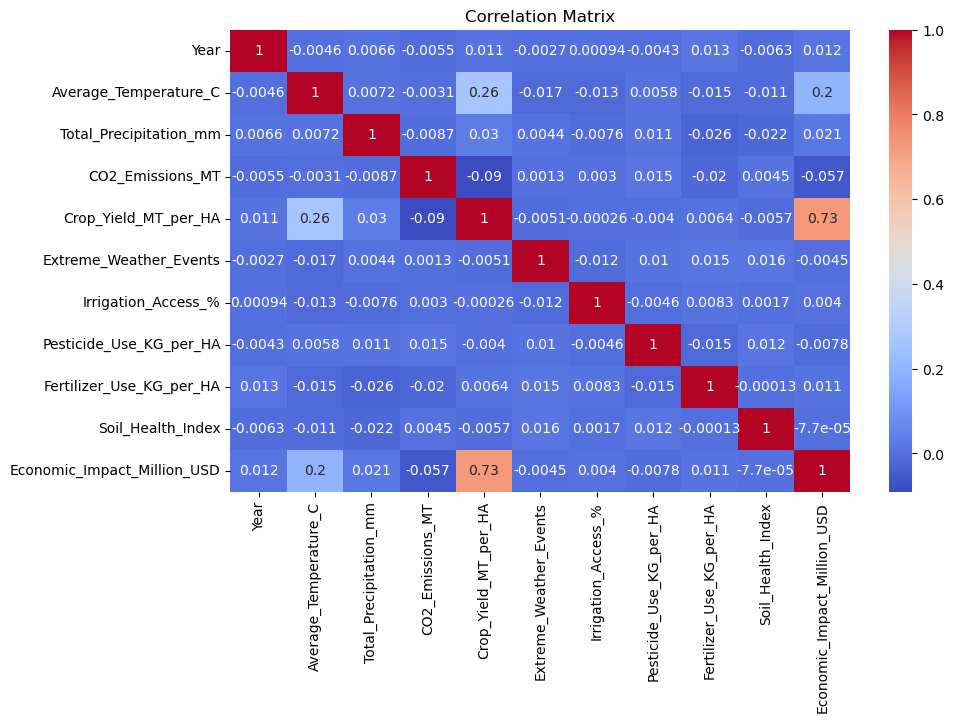

In [9]:
correlation = df.corr(numeric_only=True)
plt.figure(figsize=(10,6))
sns.heatmap(correlation, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

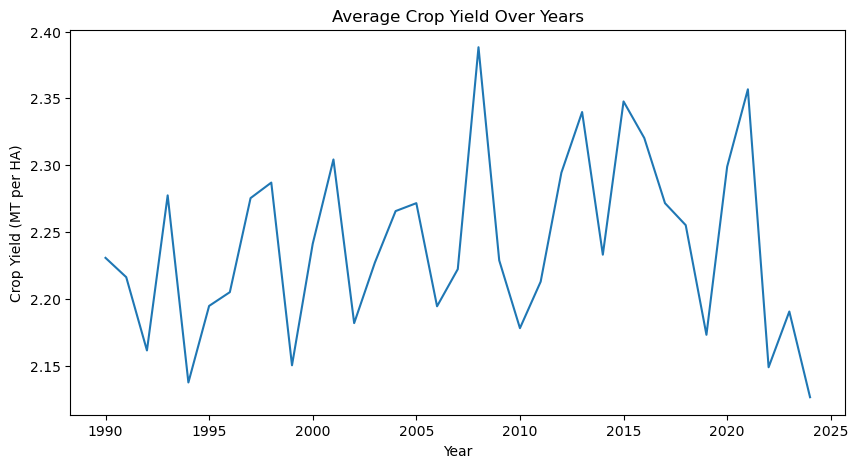

In [10]:
yearly_yield = df.groupby("Year")["Crop_Yield_MT_per_HA"].mean()
plt.figure(figsize=(10,5))
plt.plot(yearly_yield.index, yearly_yield.values)
plt.title("Average Crop Yield Over Years")
plt.xlabel("Year")
plt.ylabel("Crop Yield (MT per HA)")
plt.show()

In [11]:
yearly_yield = df.groupby("Year")["Crop_Yield_MT_per_HA"].mean().reset_index()
X = yearly_yield["Year"].values.reshape(-1,1)
y = yearly_yield["Crop_Yield_MT_per_HA"].values
yearly_yield

,Year,Crop_Yield_MT_per_HA
0,1990,2.230624
1,1991,2.216175
2,1992,2.161310
3,1993,2.277397
4,1994,2.137331
5,1995,2.194639
6,1996,2.204939
7,1997,2.275345
8,1998,2.286967
9,1999,2.150197


In [12]:
future_years = np.array([2025, 2026, 2027, 2028, 2029]).reshape(-1,1)
predicted_yield = model.predict(future_years)
for year, pred in zip(future_years, predicted_yield):
    print(f"Predicted Yield for {year[0]}: {pred:.2f}")

NameError: name 'model' is not defined

NameError: name 'predicted_yield' is not defined

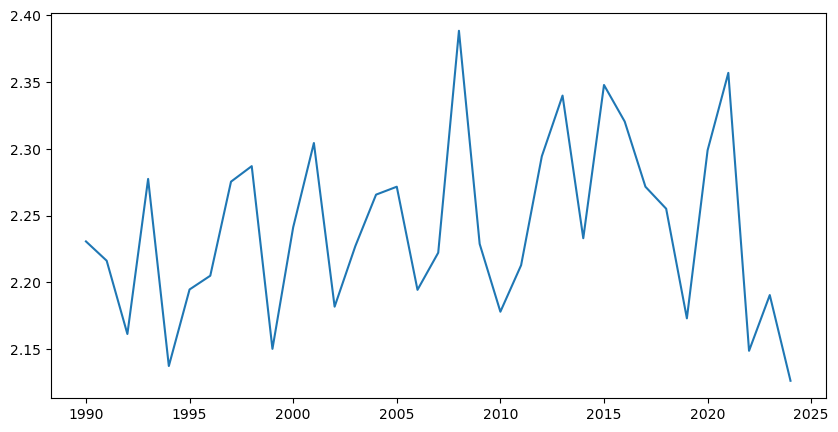

In [13]:
plt.figure(figsize=(10,5))
plt.plot(X, y, label="Actual Yield")
plt.plot(future_years, predicted_yield, linestyle="dashed", label="Forecast")
plt.title("Crop Yield Forecast")
plt.xlabel("Year")
plt.ylabel("Crop Yield (MT per HA)")
plt.legend()
plt.show()

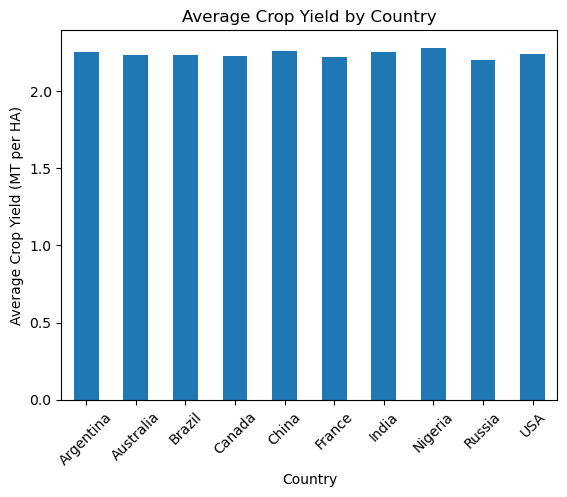

In [14]:
plt.figure()
yield_by_country.plot(kind='bar')
plt.title("Average Crop Yield by Country")
plt.xlabel("Country")
plt.ylabel("Average Crop Yield (MT per HA)")
plt.xticks(rotation=45)
plt.show()